In [ ]:
import yfinance as yf
import numpy as np
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Descargar datos del subyacente
ticker = yf.Ticker('MSFT')

#Precio spot actual
hist_spot = ticker.history(period='1d')
S0 = hist_spot['Close'].iloc[-1]
print(f' Precio spot MSFT ($S_0$): ${S0:.2f}')

#vencimiento entre 30 y 90 días
from datetime import datetime, timedelta

hoy = datetime.today()
vencimientos = ticker.options  # lista de strings 'YYYY-MM-DD'

#Filtrar vencimientos en la ventana [30, 90] días
opciones_validas = [
    v for v in vencimientos
    if 30 <= (datetime.strptime(v, '%Y-%m-%d') - hoy).days <= 90
]

#Si no hay en esa ventana, tomar el más cercano disponible
if not opciones_validas:
    opciones_validas = [vencimientos[1] if len(vencimientos) > 1 else vencimientos[0]]

fecha_exp = opciones_validas[0]
T = (datetime.strptime(fecha_exp, '%Y-%m-%d') - hoy).days / 365
print(f' Fecha de vencimiento seleccionada: {fecha_exp}  (T = {T:.4f} años)')

#Extraer cadena de opciones Call
chain = ticker.option_chain(fecha_exp)
calls_raw = chain.calls.copy()

print(f'\n Contratos Call disponibles: {len(calls_raw)}')
print(f'Columnas disponibles: {list(calls_raw.columns)}')
calls_raw.head(3)

#Parámetros del modelo
r = 0.045      
q = 0.0075     

#Limpieza de la cadena de opciones
df = calls_raw[[
    'strike', 'bid', 'ask', 'lastPrice',
    'impliedVolatility', 'volume', 'openInterest'
]].copy()

#Calcular Mid-Price (precio real de referencia)
df['midPrice'] = (df['bid'] + df['ask']) / 2

#Filtrar contratos sin liquidez real
df = df[
    (df['bid'] > 0) &
    (df['impliedVolatility'] > 0.01) &
    (df['impliedVolatility'] < 3.0) &    # eliminar valores extremos
    (df['volume'] > 0)
].reset_index(drop=True)

#Variables de entrada para ML
df['Moneyness'] = df['strike'] / S0          # K/S_t
df['T'] = T                                   # Tiempo a vencimiento (constante para este cross-section)
df['log_Moneyness'] = np.log(df['Moneyness']) # log(K/S) 

#Variable objetivo
df['IV_mercado'] = df['impliedVolatility']



print(f'Contratos útiles tras filtrado: {len(df)}')
print(f'Moneyness rango: [{df.Moneyness.min():.3f}, {df.Moneyness.max():.3f}]')
print(f'IV mercado rango: [{df.IV_mercado.min():.2%}, {df.IV_mercado.max():.2%}]')
print()


df.to_csv('opciones_msft_procesado.csv', index=False)

 Precio spot MSFT ($S_0$): $373.94
 Fecha de vencimiento seleccionada: 2026-07-24  (T = 0.0822 años)

 Contratos Call disponibles: 58
Columnas disponibles: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
Contratos útiles tras filtrado: 47
Moneyness rango: [0.722, 1.404]
IV mercado rango: [34.39%, 72.73%]



In [4]:
df_ops = pd.read_csv('opciones_msft_procesado.csv')
df_ops[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']].head(8)

,strike,Moneyness,log_Moneyness,midPrice,IV_mercado
0,270.0,0.722041,-0.325673,105.750,0.727298
1,280.0,0.748783,-0.289306,95.850,0.668704
2,290.0,0.775525,-0.254214,86.075,0.619267
3,300.0,0.802268,-0.220313,76.175,0.560185
4,305.0,0.815639,-0.203784,71.350,0.538091
5,310.0,0.829010,-0.187523,65.975,0.555424
6,315.0,0.842381,-0.171523,61.575,0.563725
7,320.0,0.855752,-0.155774,56.850,0.535649


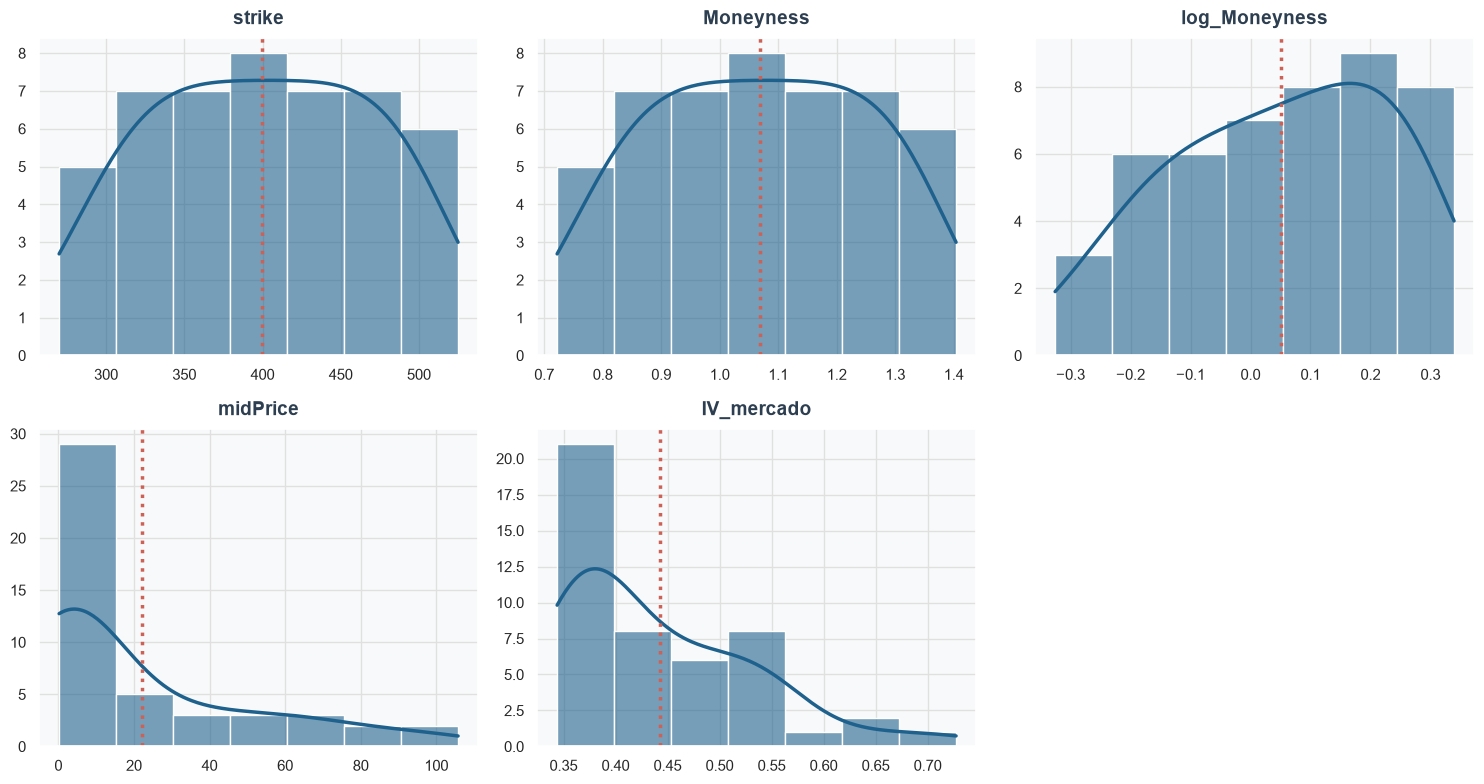

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_selec = df_ops[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']]

sns.set_theme(style="darkgrid", rc={"grid.color": "#e0e0e0", "axes.facecolor": "#f8f9fa"})

cols = 3  
rows = math.ceil(df_selec.shape[1] / cols) 
plt.figure(figsize=(15, rows * 4))


for index, (colname, serie) in enumerate(df_selec.items()):
    plt.subplot(rows, cols, index + 1)
    if pd.api.types.is_float_dtype(serie) is True :
        sns.histplot(serie, kde=True, color="#1f618d", alpha=0.6, line_kws={"linewidth": 2.5, "color": "#117a65"})
        plt.axvline(np.mean(serie), color='#cd6155', linestyle=':', linewidth=2.5)
    elif pd.api.types.is_integer_dtype(serie) is True :
        sns.countplot(x=serie, color='#1f618d')
    
    plt.title(colname, fontsize=14, fontweight='bold', color='#2c3e50', pad=10)
    plt.xlabel( '' ); plt.ylabel( '' ); plt.tight_layout()



plt.show()